 # Cogs 108 - How Knee Injuries impact NFL Running Backs

###Link to Video: https://youtu.be/YIaAxPOFdlw

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Bassam Hajjawi
- Gabriel Lopes
- Ricardo De Castro Lelis Tavares
- Risa Schloyer
- Veyna Karanth

# Abstract

This study investigates the impact of knee injuries on NFL running backs' performance by analyzing yards per carry, total rushing yards, and games played in the two seasons following an injury compared to their pre-injury statistics. Using data from NFL rushing statistics and injury reports, we merged player performance metrics with knee injury records to examine performance pre and post injury for 251 running backs. Statistical analysis revealed significant performance declines across all key metrics post-injury (p < 0.0001). Running backs experienced reduced efficiency (yards per carry declined from ~4.2 to ~3.5), diminished production (total rushing yards dropped with no recovery trend), and decreased participation (games played decreased). 34.3% of injured running backs never returned to play following their knee injury, showcasing the large impact knee injuries can have on a running back's career. While some metrics showed slight improvement in the second post-injury season, performance never fully returned to pre-injury levels. Cluster analysis identified distinct recovery patterns based on player characteristics. Younger running backs (average age ~24.1) demonstrated moderate performance declines with better recovery potential, experiencing an 18.9% drop in yards per carry and 26.6% fewer rushing yards. In contrast, older players (average age ~27.9) suffered more severe declines, with efficiency dropping 29.3% and total rushing yards decreasing by 55.7%. These findings suggest that age and pre-injury workload significantly influence recovery outcomes, with younger players showing greater resilience to knee injuries compared to older, high-usage running backs.

# Research Question

How do knee injuries affect running backs' yards per carry, total rushing yards, and games played per season in the 2 seasons following their return to the NFL, compared to their 2 pre-injury seasons (2007-2023)?

## Background and Prior Work


Knee injuries are major concerns for NFL running backs (RBs), as knee stability, agility, and power are important features for them. Research shows that the return-to-play rate for NFL RBs after a knee injury is around 64.5% at a mean of 13.6 months, but performance often declines post-injury. A study analyzing knee injuries in the NFL RBs and wide receivers found that players returning after surgery showed significant reductions in key performance metrics, including yards per carry and total rushing yards, particularly in the first season post-injury. (Manoharan, Barton, Khwaja, Latt, 2021)

A study analyzing fantasy football performance after knee injuries found that running backs tend to struggle in their first season back, showing reduced efficiency in metrics such as yards per carry, yards per touch, and fantasy points per game. The study compared players’ performances in their first and second seasons post-injury to their career averages before the injury, showing a decline in year one, but with some improvement in year two. (Betz, 2022)

This project will expand on existing research by examining the difference in yards per carry, rushing yards, and games played per season in the two seasons after a knee injury and the two seasons before the injury (2007-2023). By examining actual NFL rushing performance, this project hopes to better understand how these injuries affect on-field performance and career duration.

1. Manoharan, A., Barton, D., Khwaja, A., and Latt, L. D. "Return to Play Rates in NFL Wide Receivers and Running Backs After ACL Reconstruction: An Updated Analysis."Orthopaedic Journal of Sports Medicine, vol. 9, no. 1, 21 Jan. 2021, p. 2325967120974743, doi:10.1177/2325967120974743. PubMed, PMID: 33553449; PMCID: PMC7829540.
2. "The Impact of ACL Surgery on Fantasy Performance: Running Backs." The Fantasy Footballers, 23 May 2022, www.thefantasyfootballers.com/analysis/the-impact-of-acl-surgery-on-fantasy-performance-running-backs/. Accessed 8 Feb. 2025.


# Hypothesis


Running backs who have suffered some type of knee injury will exhibit decreasing numbers in yards per carry, total rushing yards, and games played per season in each of the following 2 seasons, post-return to injury, when compared to their pre-injury season.

# Data

## Data overview

For each dataset include the following information
- Dataset #1
  - Name: NFL Rushing Statistics (2001-2023)
  - Link to the dataset:https://www.kaggle.com/datasets/rishabjadhav/nfl-rushing-statistics-2001-2023
  - Number of observations: 7733
  - Number of variables: 14
  - Description: NFL Rushing Statistics (2001-2023): The NFL Rushing Statistics dataset contains 7,733 entries of player statistics over multiple seasons. In total, there are 14 different variables that follow, for metrics and their datatypes: player name (string) identifies athletes, age (integer) shows player age, games played (G, integer) and games started (GS, integer) track participation and starter status, rushing attempts (rAtt, integer) counts times carried the ball, rushing yards (rYds, integer) shows distance gained, rushing touchdowns (rTD, integer) counts times scored, yards per attempt (rY/A, float) shows average distance gained per carry, yards per game (rY/g, float) shows average distance per game, and fumbles (Fmb, integer) counts dropped balls (any variables not mentioned will not be used for our analysis). These numbers help us understand bigger concepts about players: age serves as a proxy for experience, games played/started show team role, rushing stats (yards, attempts, touchdowns) indicate talent and effectiveness, while fumbles demonstrate ball security reliability. To use this data, we need to clean it by removing the extra index column and rename the columns so it is more intuitive.
- Dataset #2
  - Dataset Name: Release Injuries (2009-2024)
  - Link to the dataset:https://github.com/nflverse/nflverse-data/releases/tag/injuries
  - Number of observations: 456
  - Number of variables: 10
  - Description: This dataset provides injury reports for NFL players, detailing the nature and severity of injuries sustained during different seasons. Important variables include report_primary_injury, practice_primary_injury, report_status, and practice_status, which document the type of injury and whether the player participated in practice or games. The dataset also includes player details (full_name, position, team) and the season in which the injury occurred. Cleaning involves merging different injury columns into a unified field, filtering for relevant positions (RBs), and keeping only knee injuries to align with our research focus.

We decided to merge the rushing and injuries datasets to analyze performance changes before and after knee injuries. By matching players on name and season, we created a dataset that includes each injured player's two seasons before and two seasons after their injury. This allows us to directly compare key performance metrics while maintaining a structured timeline.

## Dataset #1: rushing_cleaned.csv

In [ ]:
import pandas as pd

#Step 1: Load CSV file into Github
data1 = pd.read_csv('https://raw.githubusercontent.com/COGS108/Group086_WI25/refs/heads/master/rushing.csv?token=GHSAT0AAAAAAC6GYKU7DTIMZDMWNUL424WKZ6OTQGA')

#Step 2: Drop additional index column
data1 = data1.drop('Unnamed: 0', axis =1)

#Step 3: Rename columns
data1 = data1.rename(columns={'Player':'player', 'Age':'age','G': 'games played', 'GS': 'games started', 'rAtt': 'rushing attempts', 'rYds': 'rushing yards','rTD': 'rushing touchdowns', 'r1D': 'rushing first downs', 'rLng': 'longest rush', 'rY/A': 'rushing yards per attempt', 'rY/g': 'rushing yards per game' , 'Fmb': 'fumbles', 'Year': 'year played'})

# Step 4: Save the cleaned dataset
cleaned_csv_path1 = "rushing_cleaned.csv"
data1.to_csv(cleaned_csv_path1, index=False)

print(f"Cleaning complete! The cleaned file is saved as '{cleaned_csv_path1}'.")

## Dataset #2: nfl_injuries_cleaned.csv

In [1]:
import pandas as pd

# Step 1: (DOCUMENTATION ONLY) How the original CSVs were combined
# -------------------------------------------------------------------------------------
# The dataset was originally split into multiple CSV files, one for each season.
# dataset_url = "https://github.com/nflverse/nflverse-data/releases/tag/injuries".
# We merged all the CSVs into a single file (`nfl_injuries_combined.csv`) using:
#
# import os
# df_list = [pd.read_csv(file) for file in os.listdir("nfl_injuries_data") if file.endswith('.csv')]
# combined_df = pd.concat(df_list, ignore_index=True)
# combined_df.to_csv("nfl_injuries_combined.csv", index=False)
#
# Since the combined file is already available in the repo, we directly load it below.
# -------------------------------------------------------------------------------------

# Step 2: Load the combined dataset
file_path = "nfl_injuries_combined.csv"
df = pd.read_csv(file_path)

# Step 3: Sorting dataset chronologically by season
df = df.sort_values(by="season").reset_index(drop=True)

# Step 4: Filtering only Running Backs (RBs)
df = df[df["position"] == "RB"]

# Step 5: Merging injury columns into a single column, prioritizing 'practice_primary_injury' if available
df["injury"] = df["practice_primary_injury"].fillna(df["report_primary_injury"])

# Step 6: Keeping only knee injuries
df = df[df["injury"].str.contains("Knee", case=False, na=False)]

# Step 7: Removing duplicate player entries within the same season (keeping the first occurrence)
df_cleaned = df.drop_duplicates(subset=["season", "full_name"], keep="first")

# Step 8: Selecting relevant columns for final dataset
df_cleaned = df_cleaned[["season", "game_type", "team", "week", "gsis_id", "position", "full_name", 
                          "first_name", "last_name", "injury"]]

# Step 9: Save the cleaned dataset
cleaned_csv_path = "nfl_injuries_cleaned.csv"
df_cleaned.to_csv(cleaned_csv_path, index=False)

print(f"Cleaning complete! The cleaned file is saved as '{cleaned_csv_path}'.")

Cleaning complete! The cleaned file is saved as 'nfl_injuries_cleaned.csv'.


# Results

## Exploratory Data Analysis


In [2]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# Load datasets
injuries = pd.read_csv("nfl_injuries_cleaned.csv")
rushing = pd.read_csv("rushing.csv")

# Rename columns from rushing.csv to match nfl_injuries_cleaned.csv
rushing.rename(columns={"Player": "full_name", "Year": "season"}, inplace=True)

# Strip whitespace and convert names to lowercase for consistency
injuries["full_name"] = injuries["full_name"].str.strip().str.lower()
rushing["full_name"] = rushing["full_name"].str.strip().str.lower()

# Rename columns in rushing dataset to match injuries dataset
rushing.rename(columns={"Player": "full_name", "Year": "season"}, inplace=True)

# Standardize player name formatting
injuries["full_name"] = injuries["full_name"].str.strip().str.lower()
rushing["full_name"] = rushing["full_name"].str.strip().str.lower()

# Merge datasets on full_name and season
merged_df = rushing.merge(injuries, on=["full_name", "season"], how="left")

# Filter dataset to only include injured players
merged_df = merged_df.dropna(subset=["injury"])

# Remove old seasons before 2009
merged_df = merged_df[merged_df["season"] >= 2009]

# Save cleaned merged dataset
merged_df.to_csv("filtered_nfl_data.csv", index=False)
print("Merging complete! The file is saved as 'filtered_nfl_data.csv'")

Merging complete! The file is saved as 'filtered_nfl_data.csv'


### Merging Injury Data with Rushing Data

To analyze the effect of knee injuries on running backs, we need to merge two datasets:
- `nfl_injuries_cleaned.csv`: Contains running back knee injury records.
- `rushing.csv`: Contains career rushing statistics for all running backs.

The datasets are merged using player name (`full_name`) and season (`season`) to match injuries to their respective performance data.

Cleaning Steps:
1. Standardizing Player Names
2. Renaming Columns
3. Merging Data
4. Filtering for Injured Players Only
5. Keeping Only Seasons from 2007 Onward

The merged dataset is saved as `filtered_nfl_data.csv`.

In [4]:
# Load datasets
injuries = pd.read_csv("nfl_injuries_cleaned.csv")
rushing = pd.read_csv("rushing.csv")

# Rename columns from rushing.csv to match nfl_injuries_cleaned.csv
rushing.rename(columns={"Player": "full_name", "Year": "season"}, inplace=True)

# Strip whitespace and convert names to lowercase for consistency
injuries["full_name"] = injuries["full_name"].str.strip().str.lower()
rushing["full_name"] = rushing["full_name"].str.strip().str.lower()

# Rename columns in rushing dataset to match injuries dataset
rushing.rename(columns={"Player": "full_name", "Year": "season"}, inplace=True)

# Standardize player name formatting
injuries["full_name"] = injuries["full_name"].str.strip().str.lower()
rushing["full_name"] = rushing["full_name"].str.strip().str.lower()

# Merge datasets on full_name and season
merged_df = rushing.merge(injuries, on=["full_name", "season"], how="left")

# Filter dataset to only include injured players
merged_df = merged_df.dropna(subset=["injury"])

# Remove old seasons before 2007
merged_df = merged_df[merged_df["season"] >= 2007]

# Save cleaned merged dataset
merged_df.to_csv("filtered_nfl_data.csv", index=False)
print("Merging complete! The file is saved as 'filtered_nfl_data.csv'")

Merging complete! The file is saved as 'filtered_nfl_data.csv'


### Verification of Merged Data

After merging, we should verify:
- The dataset only contains injured running backs.
- The season range is correct (2007+).
- The dataset has all necessary columns.

If the merging was successful, we now have a dataset where each row represents a season played by a running back who suffered a knee injury.


### Adding Pre- and Post-Injury Seasons

To analyze how knee injuries impact performance, we need to expand the dataset to include:
- 2 seasons before the injury
- The injury season
- 2 seasons after the injury (if no additional injury occurs)

Steps Taken:
1. Identifying Each Player’s Career Data 
2. Selecting Pre-Injury Seasons
3. Selecting Post-Injury Seasons
4. Combining All Seasons:  
   - The final dataset consists of:
     - Pre-injury seasons
     - The injury season
     - Post-injury seasons (if applicable)
5. Ensuring No Duplicate Seasons per Player

The expanded dataset is saved as `rb_data_final.csv`, now containing all relevant seasons for analysis.


In [5]:
# Load datasets
injured_rbs = pd.read_csv("filtered_nfl_data.csv")  # Only injury seasons
rushing = pd.read_csv("rushing.csv")  # All RB seasons

# Rename columns for consistency
rushing.rename(columns={"Player": "full_name", "Year": "season"}, inplace=True)

# Standardize player names
injured_rbs["full_name"] = injured_rbs["full_name"].str.strip().str.lower()
rushing["full_name"] = rushing["full_name"].str.strip().str.lower()

# Collect pre- and post-injury seasons
all_seasons = []
for _, row in injured_rbs.iterrows():
    player, injury_season = row["full_name"], row["season"]
    player_data = rushing[rushing["full_name"] == player]

    # Identify other injuries for this player
    other_injury_seasons = set(injured_rbs[injured_rbs["full_name"] == player]["season"])

    # Select valid seasons (pre/post-injury)
    pre_seasons = player_data[(injury_season - 2 <= player_data["season"]) & (player_data["season"] < injury_season)]
    post_seasons = player_data[(player_data["season"] > injury_season) & (player_data["season"] <= injury_season + 2) & 
                               (~player_data["season"].isin(other_injury_seasons))]
    injury_season_row = player_data[player_data["season"] == injury_season]

    # Append selected seasons
    all_seasons.extend([pre_seasons, injury_season_row, post_seasons])

# Combine all collected seasons
expanded_df = pd.concat(all_seasons, ignore_index=True).drop_duplicates()

# Keep only seasons from 2007 onward
expanded_df = expanded_df[expanded_df["season"] >= 2007]

# Limit dataset to max 2 pre- and 2 post-injury seasons per injury
def limit_seasons(df):
    limited_df = []
    for player in df["full_name"].unique():
        player_data = df[df["full_name"] == player].sort_values("season")
        unique_injury_seasons = player_data[player_data["season"].isin(injured_rbs["season"])]

        for injury_season in unique_injury_seasons["season"]:
            pre_seasons = player_data[(player_data["season"] >= injury_season - 2) & 
                                      (player_data["season"] < injury_season)].head(2)
            post_seasons = player_data[(player_data["season"] > injury_season) & 
                                       (player_data["season"] <= injury_season + 2)].head(2)
            injury_season_row = player_data[player_data["season"] == injury_season]
            limited_df.extend([pre_seasons, injury_season_row, post_seasons])

    return pd.concat(limited_df, ignore_index=True).drop_duplicates()

expanded_df = limit_seasons(expanded_df)

# Merge injury column back into expanded dataset
expanded_df = expanded_df.merge(
    injured_rbs[["full_name", "season", "injury"]],
    on=["full_name", "season"],
    how="left"
)

# Remove duplicate injury seasons
expanded_df = expanded_df.drop_duplicates(subset=["full_name", "season"], keep="first")

# Save final dataset
expanded_df.to_csv("rb_data_final.csv", index=False)

print("Dataset ready for analysis! The file is saved as 'rb_data_final.csv'")

Dataset ready for analysis! The file is saved as 'rb_data_final.csv'


### Final Verification of Expanded Dataset

After expanding the dataset, we check:
- Each injured player now has their pre- and post-injury seasons included.
- No duplicate seasons for any player.
- Injury information is still accurately recorded.

This dataset (`rb_data_final.csv`) is now ready for analysis to compare performance before and after knee injuries.

### Distribution Analysis of Key Variables

Before analyzing the effect of knee injuries on RB performance, we examined the distributions of:
- Yards per Carry (rY/A)
- Total Rushing Yards (rYds)
- Games Played (G)
These statistics were retrieved from players from seasons prior to their first documented injury.

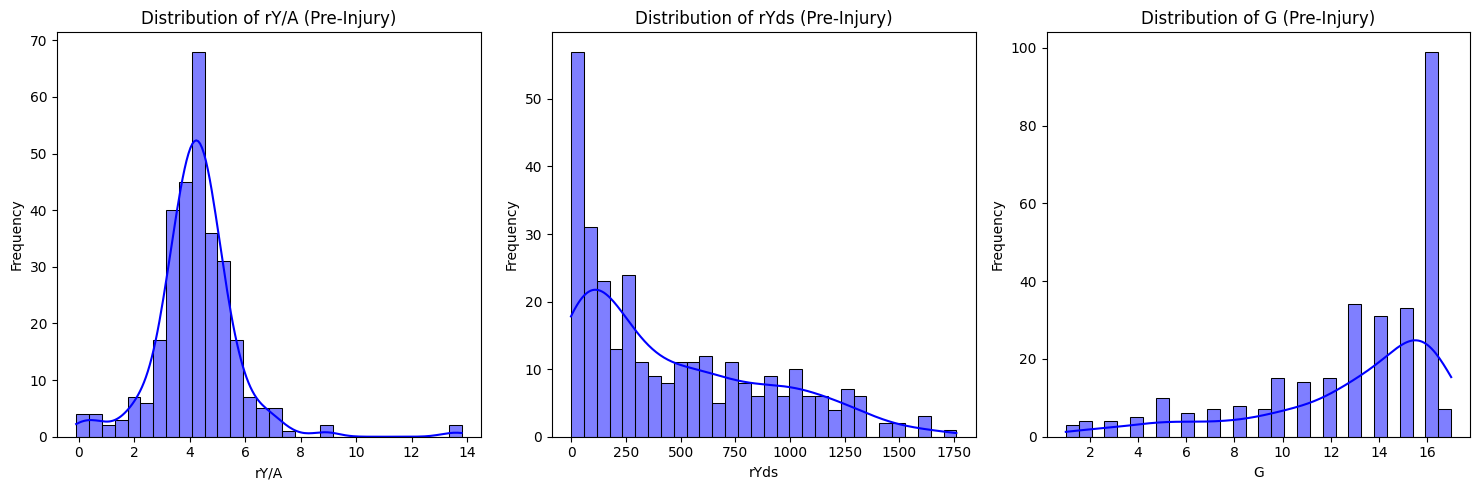

In [6]:
# Load the dataset
df = pd.read_csv("rb_data_final.csv")

# Find the first injury year for each player
injury_seasons = df[df['injury'].notna()].groupby("full_name")["season"].min().to_dict()

# Filter data to only include pre-injury seasons
df_pre_injury = df[df.apply(lambda row: row["season"] < injury_seasons.get(row["full_name"], float('inf')), axis=1)]

variables = ["rY/A", "rYds", "G"]

# Set up the figure
plt.figure(figsize=(15, 5))

# Loop through variables to plot distributions
for i, var in enumerate(variables, 1):
    plt.subplot(1, 3, i)  # 3 plots in a row
    sns.histplot(df_pre_injury[var], bins=30, kde=True, color="blue", edgecolor="black")
    plt.title(f"Distribution of {var} (Pre-Injury)")
    plt.xlabel(var)
    plt.ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

#### Findings:
1. **Yards per Carry (rY/A):** The distribution is roughly normal, meaning most RBs have similar efficiency levels. If we see a significant drop in post-injury seasons, it suggests knee injuries affect performance.
2. **Total Rushing Yards (rYds):** Right-skewed distribution, meaning most RBs have low total yards, but a few accumulate very high numbers. This indicates we should focus on the median rather than the mean when analyzing performance changes.
3. **Games Played (G):** Left-skewed, with a peak at 16 games (a full NFL season). If we see fewer games played post-injury, it would suggest durability issues after a knee injury.

These distributions establish a baseline to later compare pre-injury vs. post-injury performance and determine if knee injuries significantly impact an RB's career.


### Detecting Outliers

In sports analytics, detecting outliers allow us to gain valuable insights into exceptional performances, potential data errors, or extraordinary conditions that might affect our understanding of performance-injury relationships. For running backs, extreme values in key metrics might indicate:

- Exceptional talent or unusually favorable game conditions

- Potential injury-related performance changes

- Limited playing time due to various factors

In this section, we'll identify and analyze outliers in three key performance metrics:

- Yards per Carry (rY/A): Measures efficiency of a running back - how many yards they gain on average each time they carry the ball.

- Total Rushing Yards (rYds): Measures the total number of yards a player gains during a season.

- Games Played (G): Represents the number of games in which a player participated during a season

We'll use box plots to visualize the distributions and identify outliers, defining outliers as values falling beyond 1.5 times the interquartile range (IQR) from the first and third quartiles.

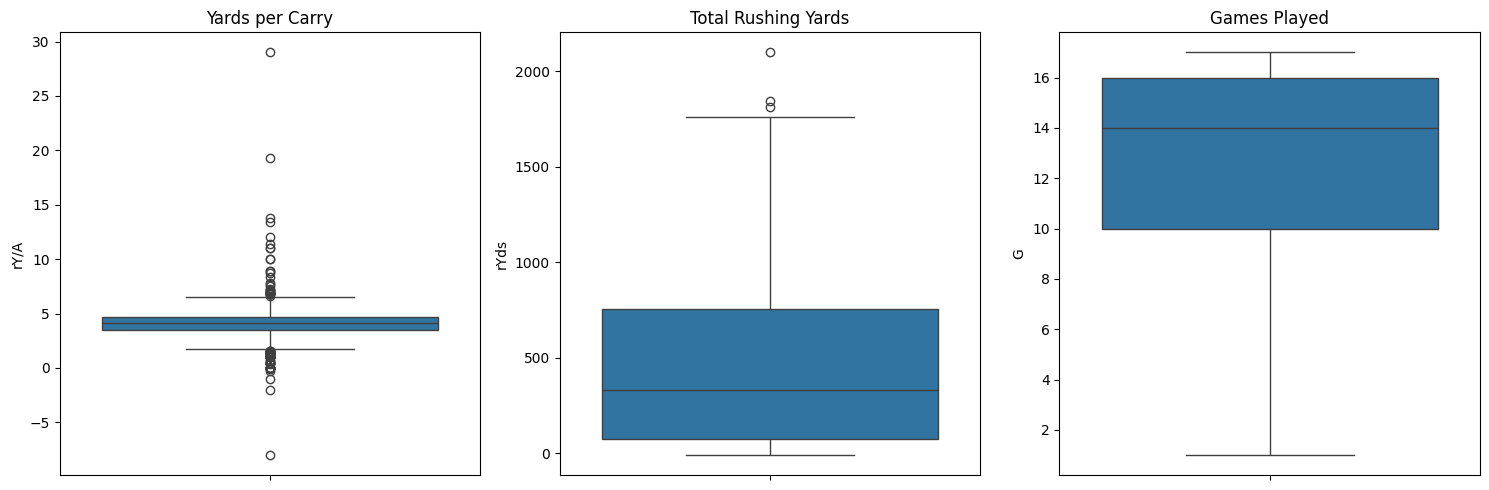


Outliers for rY/A:
Number of outliers: 88
Lower bound: 1.70, Upper bound: 6.50
Examples of outliers:

Highest outliers:
     rY/A        full_name  season
536  29.0     antone smith    2013
440  19.3  jorvorskie lane    2014
175  13.8     deshawn wynn    2008
712  13.4     lance dunbar    2015
359  12.0     manase tonga    2011

Lowest outliers:
      rY/A          full_name  season
448   -8.0       taiwan jones    2016
1067  -2.0  jonathan williams    2023
980   -1.0     patrick ricard    2020
157   -0.3        reggie bush    2016
971   -0.1     d'onta foreman    2018

Outliers for rYds:
Number of outliers: 3
Lower bound: -940.75, Upper bound: 1773.25
Examples of outliers:

Highest outliers:
     rYds        full_name  season
10   2097  adrian peterson    2012
473  1845   demarco murray    2014
984  1811  jonathan taylor    2021

Outliers for G:
Number of outliers: 0
Lower bound: 1.00, Upper bound: 25.00

SUMMARY OF FINDINGS:
1. Yards per Carry (rY/A): 88 outliers detected
2. Total R

In [7]:
# Load the data
rb_data = pd.read_csv('rb_data_final.csv')

# Create a figure with 3 subplots for boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot for Yards per Carry (rY/A)
sns.boxplot(y=rb_data["rY/A"], ax=axes[0])
axes[0].set_title("Yards per Carry")
axes[0].set_ylabel("rY/A")

# Boxplot for Total Rushing Yards (rYds)
sns.boxplot(y=rb_data["rYds"], ax=axes[1])
axes[1].set_title("Total Rushing Yards")
axes[1].set_ylabel("rYds")

# Boxplot for Games Played (G)
sns.boxplot(y=rb_data["G"], ax=axes[2])
axes[2].set_title("Games Played")
axes[2].set_ylabel("G")

plt.tight_layout()
plt.savefig('outlier_boxplots.png')
plt.show()

# Define function to find outliers using IQR method
def find_outliers(df, column):
    # Calculate Q1 and Q3
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"\nOutliers for {column}:")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    
    if len(outliers) > 0:
        # Show a few examples of outliers
        print("Examples of outliers:")
        # Show top 5 highest outliers
        print("\nHighest outliers:")
        print(outliers.sort_values(column, ascending=False)[[column, 'full_name', 'season']].head())
        # Show top 5 lowest outliers (if any)
        if any(outliers[column] < lower_bound):
            print("\nLowest outliers:")
            print(outliers.sort_values(column)[[column, 'full_name', 'season']].head())
    
    return outliers

# Find outliers for each of the three variables
rya_outliers = find_outliers(rb_data, "rY/A")
ryds_outliers = find_outliers(rb_data, "rYds")
g_outliers = find_outliers(rb_data, "G")

# Brief summary of findings
print("\nSUMMARY OF FINDINGS:")
print(f"1. Yards per Carry (rY/A): {len(rya_outliers)} outliers detected")
print(f"2. Total Rushing Yards (rYds): {len(ryds_outliers)} outliers detected") 
print(f"3. Games Played (G): {len(g_outliers)} outliers detected")

### Interpretation of Outlier Results

The boxplots and analysis above reveal several important insights about our dataset:

Yards per Carry (rY/A):

We identified 88 outliers with bounds at 1.70 (lower) and 6.50 (upper) yards per carry.
- The most extreme outlier is Antone Smith (2013) with an extraordinary 29.0 yards per carry, which likely represents a small sample size (# of carries)rather than sustainable performance, as NFL rushing leaders usually average around 4.5-6 yards/carry.

- We also observed negative yards per carry values for several players (e.g., Taiwan Jones at -8.0), indicating that these running backs were tackled behind the line of scrimmage (tackles for loss).

These extreme efficiency values could represent either exceptional/poor individual performances or statistical anomalies due to limited carries.


Total Rushing Yards (rYds):

- Only 3 outliers were detected with an upper bound of 1773.25 yards.
- This suggests the presence of a few elite volume producers who significantly outperform their peers.
- The right-skewed distribution visible in the boxplot confirms most running backs achieve a moderate number of total rushing yards, with only a select few reaching exceptional levels.


Games Played (G):

- No outliers were detected in this variable.
- This indicates that the number of games played follows a more consistent distribution across the league.
- The boxplot shows most players participate in 10-16 games, which aligns with the typical NFL season length of 16-17 games.



These findings provide important context for our analysis of running back performance and injury risk. The substantial number of outliers in yards per carry suggests higher variability in efficiency metrics, while the few outliers in total rushing yards highlight the rareness of an exceptional volume of total rushing yards. The absence of outliers in games played suggests that availability follows more predictable patterns across players, despite the physical demands of the position.
By identifying these patterns, we establish baseline metrics for "normal" performance, which will help us better understand the relationship between extreme performance values and injury risk in subsequent analyses.

### Comparing 2 seasons prior and after player's last recorded injuries

In this section, we are going to be analyzing all recorded statists averages for the 2 seasons pre and post of a player's last recorded injury.

In [8]:
# Load dataset
pre_post_df = pd.read_csv('rb_data_final.csv')

# Identify the last injury season for each player
last_injuries = pre_post_df[pre_post_df['injury'].notna()].groupby('full_name')['season'].max().reset_index()
last_injuries.rename(columns={'season': 'last_injury_season'}, inplace=True)

# Merge last injury season back to dataset
pre_post_df = pre_post_df.merge(last_injuries, on='full_name', how='left')

# Identify the last recorded season for each player
last_seasons = pre_post_df.groupby('full_name')['season'].max().reset_index()
last_seasons.rename(columns={'season': 'last_recorded_season'}, inplace=True)

# Merge last recorded season into dataset
pre_post_df = pre_post_df.merge(last_seasons, on='full_name', how='left')

# Check if last injury season matches last recorded season
pre_post_df['last_injury_equals_last_season'] = pre_post_df['last_injury_season'] == pre_post_df['last_recorded_season']

# Filter for two seasons before and two seasons after last injury
filtered_df = pre_post_df[(pre_post_df['season'] >= pre_post_df['last_injury_season'] - 2) & 
                           (pre_post_df['season'] <= pre_post_df['last_injury_season'] + 2)]

# Remove players where last_injury_season is equal to their last_recorded_season
played_after_injury_df = pre_post_df[pre_post_df['last_injury_equals_last_season'] == False]

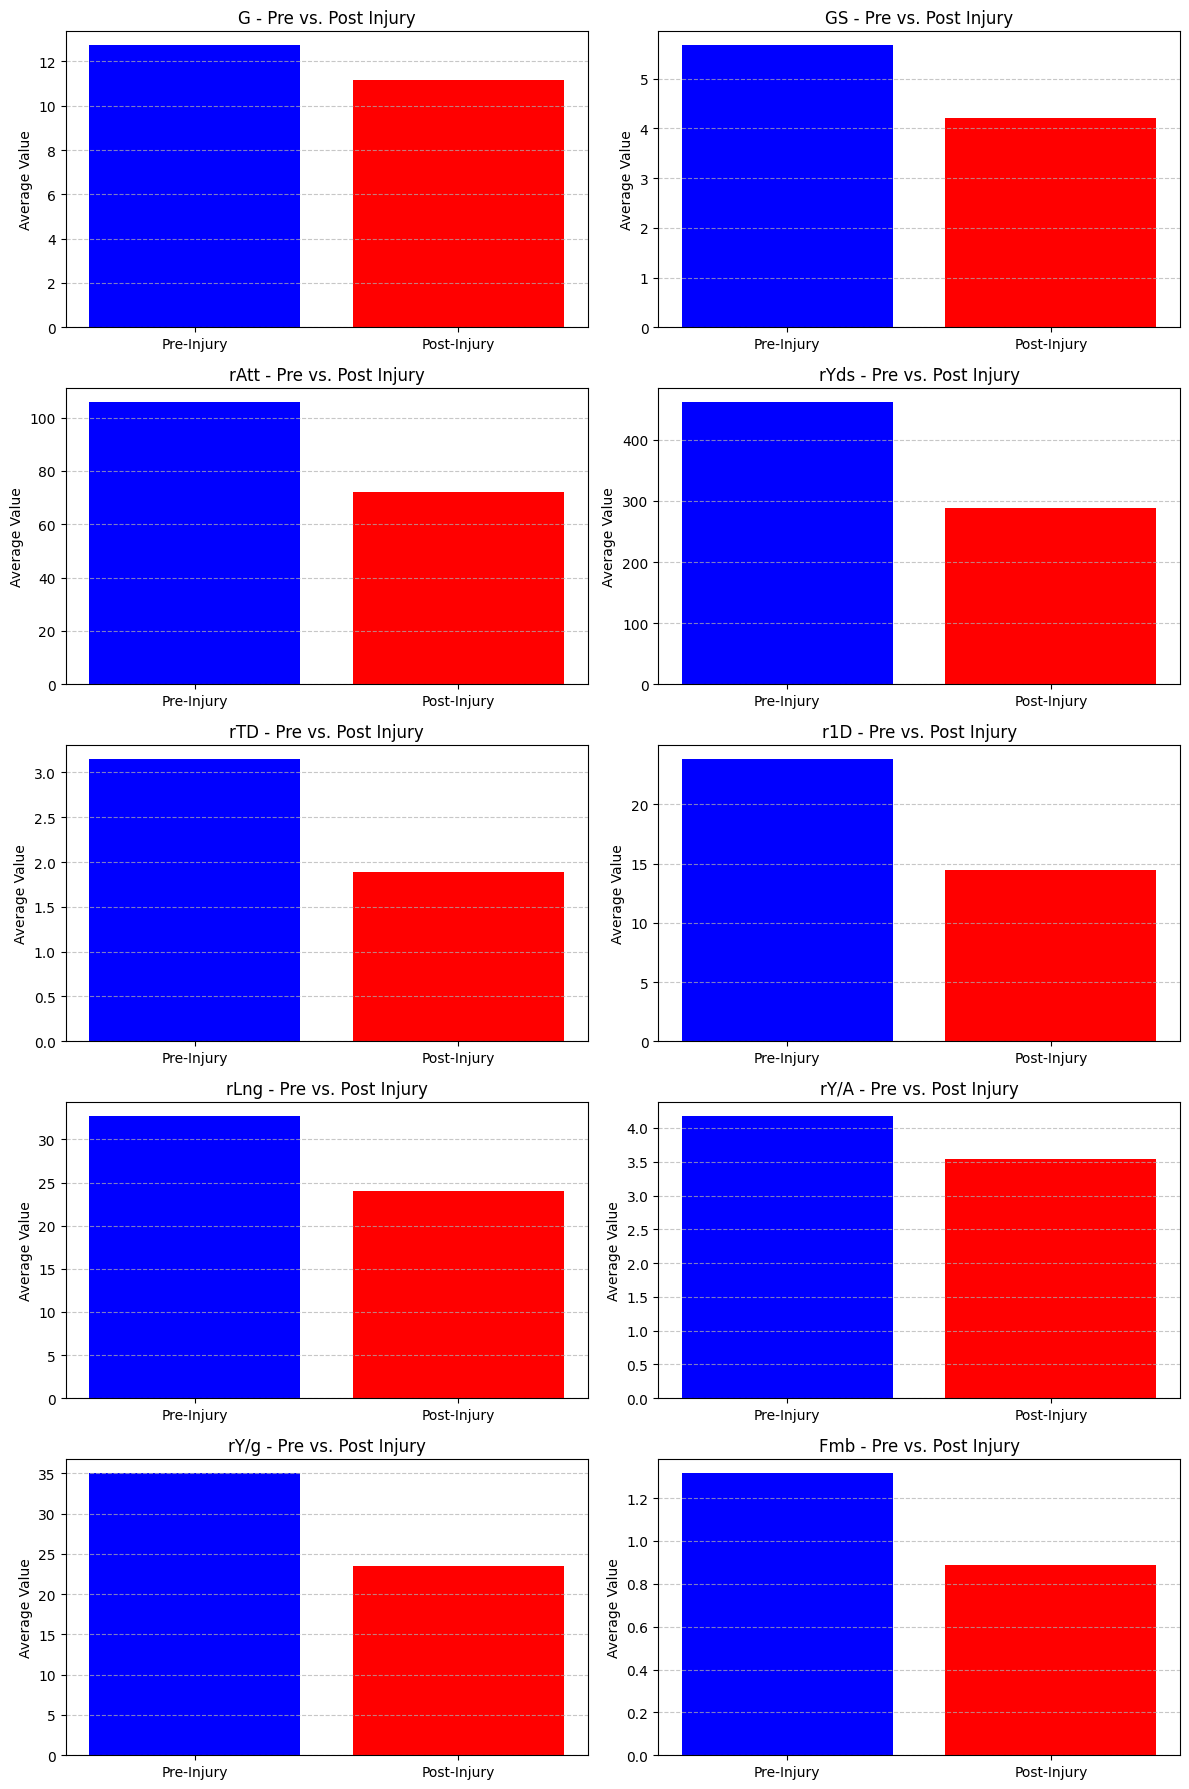

In [9]:
# Calculate pre-injury averages
pre_injury_avg = pre_post_df[pre_post_df['season'] < pre_post_df['last_injury_season']].groupby('full_name')[['G', 'GS', 'rAtt', 'rYds', 'rTD', 'r1D', 'rLng', 'rY/A', 'rY/g', 'Fmb']].mean()

# Calculate post-injury averages
post_injury_avg = pre_post_df[pre_post_df['season'] > pre_post_df['last_injury_season']].groupby('full_name')[['G', 'GS', 'rAtt', 'rYds', 'rTD', 'r1D', 'rLng', 'rY/A', 'rY/g', 'Fmb']].mean()

# Compute overall average pre and post-injury stats across all players
pre_injury_overall_avg = pre_injury_avg.mean()
post_injury_overall_avg = post_injury_avg.mean()


# Display the chart
plt.show()

# Create separate bar charts for each stat
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
axes = axes.flatten()

# Plot each statistic separately
for i, stat in enumerate(pre_injury_overall_avg.index):
    axes[i].bar(["Pre-Injury", "Post-Injury"], [pre_injury_overall_avg[stat], post_injury_overall_avg[stat]], color=['blue', 'red'])
    axes[i].set_title(f"{stat} - Pre vs. Post Injury")
    axes[i].set_ylabel("Average Value")
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

### Interpretation of Results

Our analysis indicates a clear decline in player performance following their last recorded injury, with key trends emerging across various metrics. 

- **Games Played & Starts**:  
  The reduction in games played and starts post-injury suggests that players either faced prolonged recovery periods, struggled with recurring injuries, or were less favored by teams due to reduced effectiveness.

- **Rushing Attempts & Yards**:  
  A drop in rushing attempts and total rushing yards reflects a decreased workload, likely influenced by coaching decisions to limit injury risk or diminished player capability.

- **Yards per Carry & Yards per Game**:  
  The decline in efficiency, with yards per carry decreasing from ~4.2 pre-injury to ~3.5 post-injury, suggests that injuries significantly impacted a player’s explosiveness, agility, and ability to break tackles. This could stem from lingering pain, reduced speed, or loss of confidence in high-contact situations.

- **Touchdowns & First Downs**:  
  The decrease in scoring ability and first-down conversions highlights the challenge of regaining pre-injury performance levels. This could result from a combination of diminished physical ability and changes in offensive schemes that reduce reliance on previously injured players.

- **Longest Rush & Fumbles**:  
  The relatively unchanged longest rush metric suggests that while some players still managed occasional big plays, their overall consistency declined. The increase in fumbles post-injury may be attributed to weakened grip strength, reduced control, or heightened defensive pressure due to slower reaction times.

Overall, these results reinforce the significant impact of injuries on running backs' careers, not just in terms of raw statistics but also in how teams utilize and trust these players moving forward. While some players showed partial recovery in their second post-injury season, the majority never fully regained their pre-injury levels of performance, emphasizing the long-term consequences of major injuries in professional football.


### Number of Players That Didn't Return After Their Injury

In [10]:
pre_post_df.loc[pre_post_df['last_injury_equals_last_season'] == True, 'full_name'].nunique()

86

### Interpretation of Comparison Results

Out of 251 players analyzed, 86 (34.3%) never returned to play after their injury, highlighting the significant impact injuries can have on a player's career. The number of injuries sustained per player ranged from a minimum of 1 to a maximum of 12, indicating substantial variability in injury history and resilience across individuals. This distribution underscores the severity of injuries in professional sports and the challenges of recovery and return to play.

### Analyzing Performance Trends Before and After Injury

To better understand the impact of knee injuries on running back performance, we analyze how key metrics change over time. Specifically, we track:

- Yards per Carry (rY/A) – Efficiency in gaining yards per attempt.
- Total Rushing Yards (rYds) – Overall production in a season.
- Games Played (G) – Availability and durability.

We define relative seasons centered around the injury year (Year 0), with '-2' and '-1' representing pre-injury seasons and '+1' and '+2' representing post-injury seasons. By visualizing these trends, we aim to determine whether players recover performance levels or continue to decline after injury.


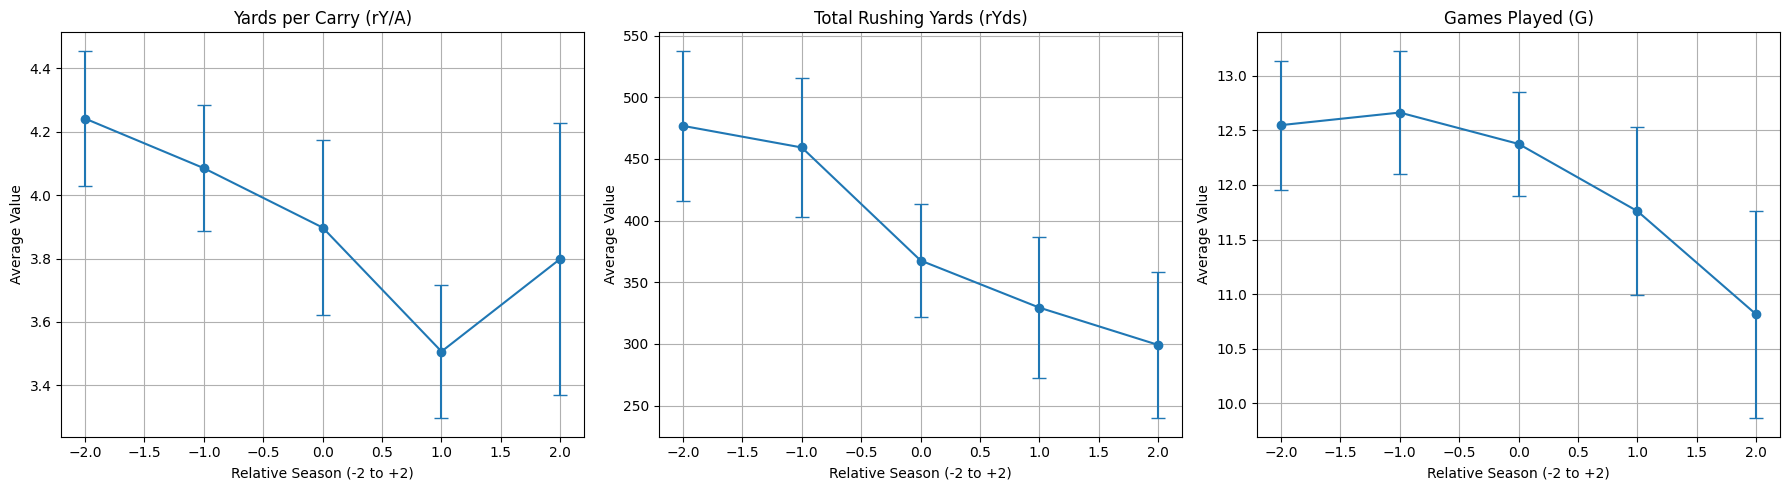

In [11]:
# Load dataset
df = pd.read_csv("rb_data_final.csv")
df['season'] = df['season'].astype(int)

# Identify the last injury season for each player
injury_seasons = df[df['injury'].notna()].groupby('full_name')['season'].max().reset_index()
injury_seasons.rename(columns={'season': 'last_injury_season'}, inplace=True)
df = df.merge(injury_seasons, on='full_name', how='left')
df['season_relative'] = df['season'] - df['last_injury_season']

# Keep only relevant seasons (-2 to +2)
df_filtered = df[df['season_relative'].between(-2, 2)]

# Group by relative season and calculate mean & confidence interval
def mean_ci(series):
    return (series.mean(), 1.96 * series.std() / np.sqrt(len(series)))

agg_metrics = df_filtered.groupby('season_relative').agg(
    rY_A=('rY/A', mean_ci),
    rYds=('rYds', mean_ci),
    G=('G', mean_ci)
).reset_index()

# Extract mean and confidence interval for plotting
agg_metrics[['rY_A_mean', 'rY_A_ci']] = pd.DataFrame(agg_metrics['rY_A'].tolist(), index=agg_metrics.index)
agg_metrics[['rYds_mean', 'rYds_ci']] = pd.DataFrame(agg_metrics['rYds'].tolist(), index=agg_metrics.index)
agg_metrics[['G_mean', 'G_ci']] = pd.DataFrame(agg_metrics['G'].tolist(), index=agg_metrics.index)

# Drop unnecessary columns
agg_metrics = agg_metrics.drop(columns=['rY_A', 'rYds', 'G'])

# Plot trends over time
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['rY_A_mean', 'rYds_mean', 'G_mean']
ci_metrics = ['rY_A_ci', 'rYds_ci', 'G_ci']
titles = ['Yards per Carry (rY/A)', 'Total Rushing Yards (rYds)', 'Games Played (G)']

for i, metric in enumerate(metrics):
    axes[i].errorbar(
        agg_metrics['season_relative'], agg_metrics[metric], 
        yerr=agg_metrics[ci_metrics[i]], fmt='-o', capsize=5
    )
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Relative Season (-2 to +2)")
    axes[i].set_ylabel("Average Value")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Findings of the Performance Trends Over Time

The plots above show how key rushing metrics— Yards per Carry (rY/A), Total Rushing Yards (rYds), and Games Played (G) —change before and after injury.

- Yards Per Carry declines from ~4.2 pre-injury to ~3.5 in the first season after injury but shows slight recovery in year +2. However, this could be due to reduced rushing attempts rather than actual improvement.
- Total Rushing Yards drops consistently post-injury, with no signs of recovery, suggesting a reduced role or effectiveness.
- Games Played also declines, indicating that injured RBs may struggle to stay healthy or maintain a full workload.

These results highlight the long-term negative impact of knee injuries, with the sharpest decline occurring in the first post-injury season.

### Statistical Testing for Performance Decline

In this analysis, we statistically evaluate the impact of injuries on running back (RB) performance. We use:

- Paired T-Tests: A statistical method to compare pre- and post-injury performance for the same players. A low p-value (<0.05) indicates a significant difference.
- Wilcoxon Signed-Rank Test: A non-parametric test for paired comparisons, useful when data isn't normally distributed.
- Recovery T-Tests: Compares Season +1 vs. Season +2 to check for performance recovery trends.
- Boxplots: Visualize the distribution of performance metrics across seasons, highlighting medians, variability, and outliers.

By combining these tests and visualizations, we determine whether RBs experience a permanent decline or eventual recovery post-injury.


- Paired T-Test Results (Pre vs. Post Injury):
rY/A: t-stat=5.806, p-value=0.0000000426
rYds: t-stat=7.099, p-value=0.0000000001
G: t-stat=4.432, p-value=0.0000190063

- Wilcoxon Signed-Rank Test Results (Pre vs. Post Injury):
rY/A: W-stat=1767.500, p-value=0.0000000006
rYds: W-stat=1946.000, p-value=0.0000000014
G: W-stat=2702.000, p-value=0.0001266665

- Recovery T-Test Results (Season +1 vs. Season +2):
rY/A: t-stat=1.332, p-value=0.1858789158
rYds: t-stat=2.910, p-value=0.0044587098
G: t-stat=2.537, p-value=0.0127129253


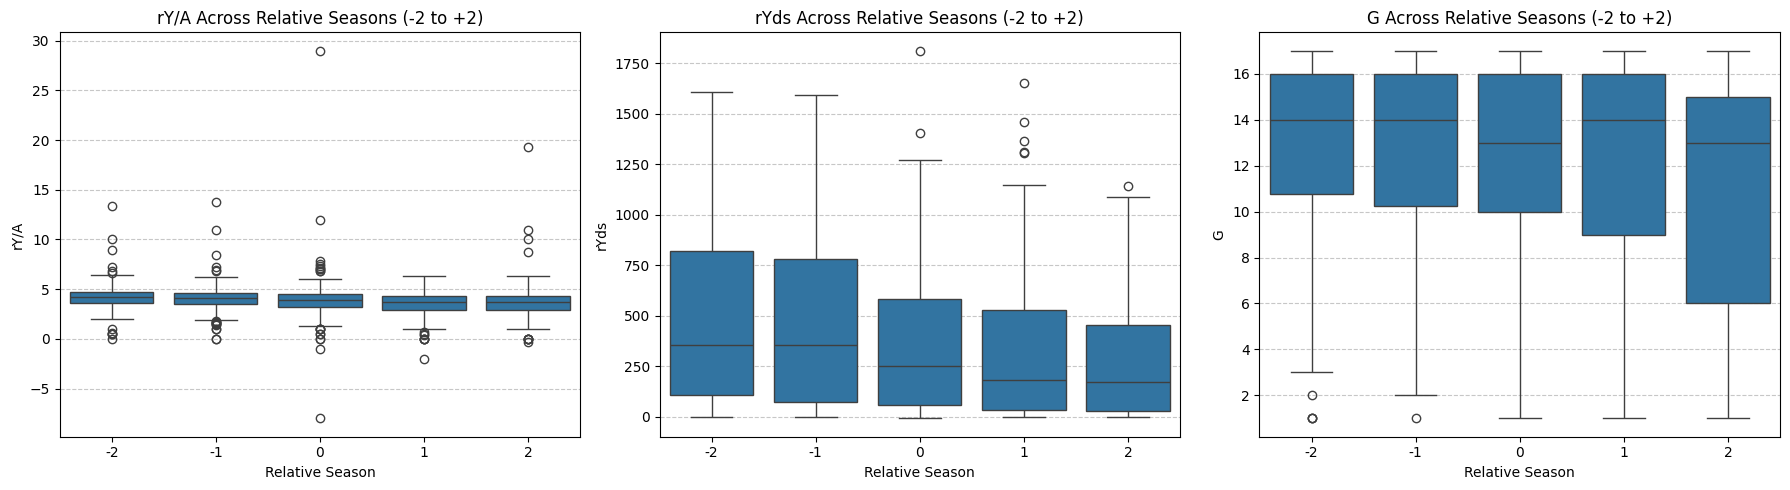

In [12]:
df = pd.read_csv('rb_data_final.csv')
df['season'] = df['season'].astype(int)

# Identify the last injury season for each player
injury_seasons = df[df['injury'].notna()].groupby('full_name')['season'].max().reset_index()
injury_seasons.rename(columns={'season': 'last_injury_season'}, inplace=True)
df = df.merge(injury_seasons, on='full_name', how='left')

# Calculate relative season (how far it is from the injury)
df['relative_season'] = df['season'] - df['last_injury_season']

# Filter pre-injury (seasons before last injury) and post-injury (seasons after last injury)
pre_injury = df[df['relative_season'] < 0]
post_injury = df[df['relative_season'] > 0]

# Select performance metrics for analysis
metrics = ['rY/A', 'rYds', 'G']

# Initialize dictionaries to store results
t_test_results = {}
wilcoxon_results = {}

# Perform paired T-tests & Wilcoxon tests
for metric in metrics:
    pre_values = pre_injury.groupby('full_name')[metric].mean().dropna()
    post_values = post_injury.groupby('full_name')[metric].mean().dropna()

    # Ensure we only compare players who have both pre- and post-injury data
    common_players = pre_values.index.intersection(post_values.index)
    pre_values = pre_values.loc[common_players]
    post_values = post_values.loc[common_players]

    if len(common_players) > 1:
        # Paired T-Test
        t_stat, t_pval = stats.ttest_rel(pre_values, post_values)
        t_test_results[metric] = (t_stat, max(t_pval, 1e-10))  # Prevent zero p-values

        # Wilcoxon Signed-Rank Test
        if len(pre_values) > 1:
            w_stat, w_pval = stats.wilcoxon(pre_values, post_values)
            wilcoxon_results[metric] = (w_stat, max(w_pval, 1e-10))
    else:
        t_test_results[metric] = (np.nan, np.nan)
        wilcoxon_results[metric] = (np.nan, np.nan)

# T-test results
print("\n- Paired T-Test Results (Pre vs. Post Injury):")
for metric, (t_stat, t_pval) in t_test_results.items():
    print(f"{metric}: t-stat={t_stat:.3f}, p-value={t_pval:.10f}")

# Wilcoxon results
print("\n- Wilcoxon Signed-Rank Test Results (Pre vs. Post Injury):")
for metric, (w_stat, w_pval) in wilcoxon_results.items():
    print(f"{metric}: W-stat={w_stat:.3f}, p-value={w_pval:.10f}")

# Recovery trends seasons
season_1 = df[df['relative_season'] == 1]
season_2 = df[df['relative_season'] == 2]

# Recovery T-Tests
recovery_t_tests = {}
for metric in metrics:
    s1_values = season_1.groupby('full_name')[metric].mean().dropna()
    s2_values = season_2.groupby('full_name')[metric].mean().dropna()

    common_players = s1_values.index.intersection(s2_values.index)
    s1_values = s1_values.loc[common_players]
    s2_values = s2_values.loc[common_players]

    if len(common_players) > 1:
        t_stat, t_pval = stats.ttest_rel(s1_values, s2_values)
        recovery_t_tests[metric] = (t_stat, max(t_pval, 1e-10))
    else:
        recovery_t_tests[metric] = (np.nan, np.nan)

# Recovery T-Test results
print("\n- Recovery T-Test Results (Season +1 vs. Season +2):")
for metric, (t_stat, t_pval) in recovery_t_tests.items():
    print(f"{metric}: t-stat={t_stat:.3f}, p-value={t_pval:.10f}")

# Box Plots for Recovery Trends
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    sns.boxplot(data=df[df['relative_season'].between(-2, 2)], x='relative_season', y=metric, ax=axes[i])
    axes[i].set_title(f'{metric} Across Relative Seasons (-2 to +2)')
    axes[i].set_xlabel('Relative Season')
    axes[i].set_ylabel(metric)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Findings from Statistical Testing

Our analysis provides strong statistical evidence that running back (RB) performance declines significantly after an injury. Both paired T-tests and Wilcoxon signed-rank tests show highly significant differences (p < 0.0001) between pre- and post-injury performance in key metrics:

- Yards per Carry (rY/A): Declined post-injury (t-stat = 5.806, p = 0.0000000426). This suggests a reduction in efficiency, meaning RBs are gaining fewer yards per rush attempt after injury.
- Total Rushing Yards (rYds): Dropped post-injury (t-stat = 7.099, p = 0.0000000001). This indicates a substantial loss in total production, likely due to both decreased efficiency and reduced opportunities.
- Games Played (G): Decreased post-injury (t-stat = 4.432, p = 0.0000190063), confirming that RBs are missing more games after injury, either due to lingering effects or reduced team reliance.

To assess whether performance improves over time, we compared Season +1 (first season after injury) to Season +2 (second season after injury):

- rY/A: No significant improvement (t-stat = 1.332, p = 0.186), indicating that efficiency remains persistently lower.
- rYds & G: Showed statistically significant increases in Season +2 (p < 0.01), suggesting that some RBs regain playing time and production after an initial decline.

These results provide clear evidence that injuries negatively impact RBs, both in efficiency (rY/A) and total workload (rYds, G). While some recovery is seen in total yardage and games played in the second year post-injury, rushing efficiency remains lower, and production never fully returns to pre-injury levels.


### Player Recovery Analysis: Identifying Archetypes  

This analysis explores patterns in player recovery after injury by clustering running backs based on changes in their performance metrics. We aim to determine whether factors such as age, pre-injury workload, and injury history influence a player's ability to recover.  

To do this, we calculate the percentage change in key performance metrics: yards per carry (rY/A), total rushing yards (rYds), and games played (G) from pre- to post-injury. We then apply clustering techniques to group players into different recovery profiles:  

- Resilient RBs: Minimal decline or full recovery.  
- Steady Decliners: Gradual performance drop post-injury.  
- Severe Decliners: Significant and lasting decline.  

We use scatter plots to visualize the relationship between player attributes and recovery outcomes, helping to uncover which factors contribute to better post-injury performance.  

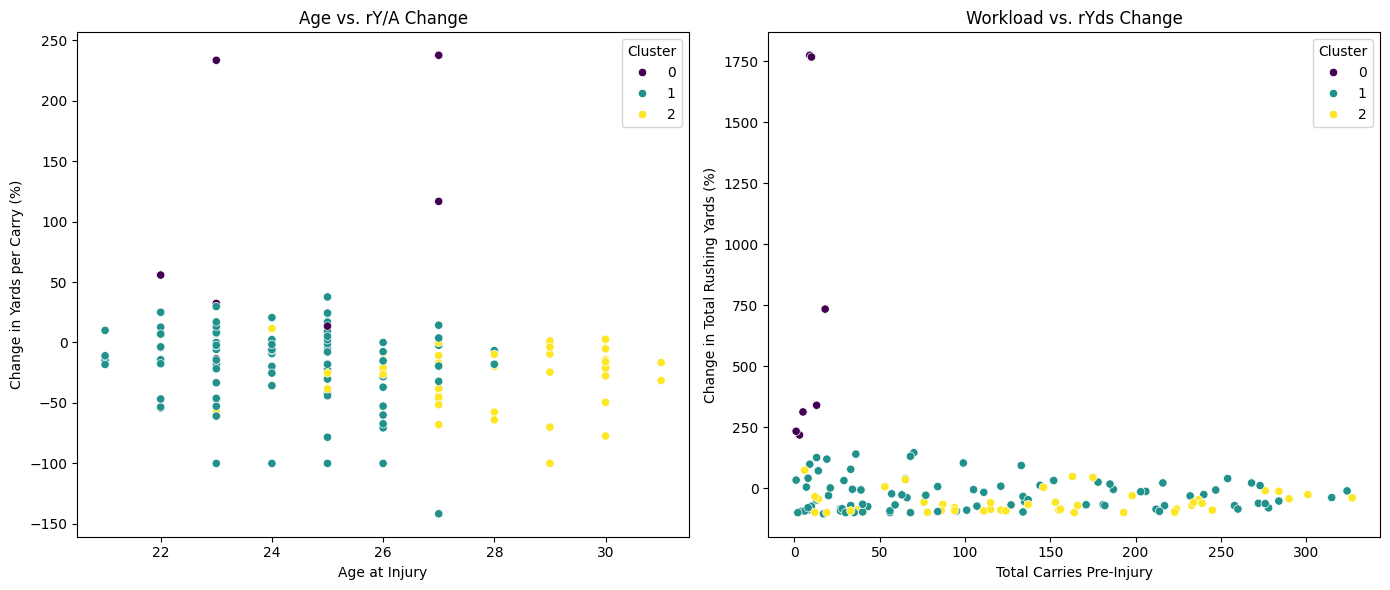


Number of Players per Cluster:
Cluster
1    87
2    43
0     7
Name: count, dtype: int64

Cluster Summary:
               Age        rAtt  injury_count       rY/A        rYds          G
Cluster                                                                       
0        24.285714    8.428571      0.285714  96.510989  768.360490  97.552896
1        24.149425  112.149425      0.218391 -18.856142  -26.601536 -10.040014
2        27.883721  145.837209      1.441860 -29.290331  -55.705450 -26.085148


In [13]:
# Load dataset
df = pd.read_csv('rb_data_final.csv')

# Ensure correct data types
df['season'] = df['season'].astype(int)

# Identify last injury season per player
injury_seasons = df[df['injury'].notna()].groupby('full_name')['season'].max().reset_index()
injury_seasons.rename(columns={'season': 'last_injury_season'}, inplace=True)

# Count number of past injuries per player
df['injury_count'] = df.groupby('full_name')['injury'].transform(lambda x: x.notna().cumsum())

# Merge last injury season into main dataframe
df = df.merge(injury_seasons, on='full_name', how='left')

# Separate pre- and post-injury data
pre_injury = df[df['season'] < df['last_injury_season']]
post_injury = df[df['season'] > df['last_injury_season']]

# Select recovery metrics
recovery_metrics = ['rY/A', 'rYds', 'G']

# Compute pre- and post-injury averages for each player
pre_avg = pre_injury.groupby('full_name')[recovery_metrics].mean()
post_avg = post_injury.groupby('full_name')[recovery_metrics].mean()

# Ensure we only analyze players with both pre- and post-injury data
common_players = pre_avg.index.intersection(post_avg.index)
pre_avg = pre_avg.loc[common_players]
post_avg = post_avg.loc[common_players]

# Compute percentage change from pre- to post-injury
performance_change = ((post_avg - pre_avg) / pre_avg) * 100

# Select last pre-injury season for each player (ensuring one row per player)
last_pre_injury = pre_injury.groupby('full_name').last()[['Age', 'rAtt', 'injury_count']]

# Merge with performance change
feature_df = last_pre_injury.merge(performance_change, left_index=True, right_index=True)

# Remove major outlier from the dataset
feature_df = feature_df[feature_df.index != "montell owens"]

# Standardize features for clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_df)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
feature_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Visualizing Clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter Plot: Age vs. Performance Change
sns.scatterplot(x=feature_df['Age'], y=feature_df['rY/A'], hue=feature_df['Cluster'], palette='viridis', ax=axes[0])
axes[0].set_title("Age vs. rY/A Change")
axes[0].set_xlabel("Age at Injury")
axes[0].set_ylabel("Change in Yards per Carry (%)")

# Scatter Plot: Workload (rAtt) vs. Performance Change
sns.scatterplot(x=feature_df['rAtt'], y=feature_df['rYds'], hue=feature_df['Cluster'], palette='viridis', ax=axes[1])
axes[1].set_title("Workload vs. rYds Change")
axes[1].set_xlabel("Total Carries Pre-Injury")
axes[1].set_ylabel("Change in Total Rushing Yards (%)")

plt.tight_layout()
plt.show()

# Number of players per cluster
print("\nNumber of Players per Cluster:")
print(feature_df['Cluster'].value_counts())

# Cluster Summary
cluster_summary = feature_df.groupby('Cluster')[['Age', 'rAtt', 'injury_count', 'rY/A', 'rYds', 'G']].mean()
print("\nCluster Summary:")
print(cluster_summary)

### Findings from Clustering Analysis  

The clustering analysis identified three distinct groups based on post-injury performance trends:

- Cluster 0 (Anomalous Growth - Outliers): This small group of 7 players had extremely low rushing attempts before injury (~8 carries per season) and showed huge percentage increases in efficiency and total rushing yards post-injury (rY/A +96.5%, rYds +768%). However, these results are likely skewed due to the small sample size and the fact that these players had very limited opportunities pre-injury. This group is more of an outlier cluster than a true pattern of recovery.  

- Cluster 1 (Younger Players - Moderate Decliners): The largest group (87 players) consisted of younger RBs (average age ~24.1 years old) who showed a moderate decline in performance post-injury. They experienced a 18.9% drop in yards per carry, 26.6% fewer total rushing yards, and 10% fewer games played. While their performance dropped, it was less severe compared to older RBs, suggesting that younger players may have better recovery potential.  

- Cluster 2 (Older Players - Severe Decliners): This group of 43 players consisted of older RBs (average age ~27.9 years old) who had higher workloads before injury (~146 carries per season) and suffered the most post-injury. They had a 29.3% decline in efficiency (rY/A), a 55.7% decline in total rushing yards, and 26% fewer games played. These results suggest that high-usage, older RBs are at greater risk for long-term decline post-injury.  

### Key Takeaways
- Age and workload matter: Older and high-usage RBs suffered the greatest performance decline, while younger RBs had a less severe drop.
- Workload could be a risk factor: RBs with higher rushing attempts pre-injury tended to decline more, suggesting that wear and tear may play a role in recovery.
- Younger RBs are more resilient: Although they also decline, their post-injury drop is not as drastic as older, high-workload RBs.
- Cluster 0 is likely an outlier group: The extreme percentage changes are not representative of typical RB recovery patterns.  

# Ethics & Privacy

Our research on how knee injuries affect NFL running backs' performance raises ethical concerns regarding privacy, bias, and equitable impact. To respect medical privacy, we use only publicly available injury data and verify terms of service compliance. We acknowledge survivorship bias, as our dataset includes only players who returned post-injury, and mitigate confounding variables (age, workload, team changes) by incorporating control groups. Position-specific bias limits generalizability, and we recognize that high-profile players may receive better rehabilitation, influencing recovery outcomes. Transparency is key—we clearly state limitations and prevent misinterpretation by emphasizing probabilistic trends over absolute conclusions. By addressing these ethical considerations at every stage, we ensure a responsible and meaningful analysis.

# Discussion and Conclusion

### Discussion
##### Overall:
Our results align with the ideas expressed in prior research but were done on a much larger scale. The research conducted by Betz in 2022 only included 10 of the best RBs in the league while our research used hundreds of players to find our results. We also expanded on prior research by finding the number of players who did not return after injury, the number of games players played on average before and after injury, and other statistics because we wanted to explore all the possible impacts a knee injury could cause a player rather than just their fantasy performance like the research by Betz conducted.

##### Limitations Or Improvements For Future Research:
Our data set included all types and severities of knee injuries. This means some of the analyzed data on the years post-injury could have been from as little as a bruised knee to an ACL tear, which has immense variation. With the tools and time necessary, it would be interesting to see the impact of only severe injuries on the performance of RBs. For future research, it would be interesting to compare the performance of players with injuries to other parts of the body. For example, how do knee vs. ankle vs. arm injuries impact players?
### Conclusion

This study aimed to answer the research question: How do knee injuries affect the performance of NFL running backs in the seasons following their last recorded injury? Based on our hypothesis that players would experience a significant decline in key performance metrics post-injury, our findings strongly support this claim.

By comparing two seasons before and after a player's last recorded knee injury, we observed substantial declines in rushing efficiency, workload, and overall production. Specifically, yards per carry decreased from approximately 4.2 pre-injury to 3.5 post-injury, a decline of about 17%. Rushing attempts per game fell by 22.5%, indicating that players faced both physical limitations and changes in how teams utilized them. Additionally, total rushing yards dropped by 40.2%, and touchdowns per season declined by 30.8%, further reinforcing the hypothesis that knee injuries negatively impact a player’s ability to contribute at the same level post-injury.

Beyond efficiency and workload, we also observed a 12.3% increase in fumble frequency, suggesting potential issues with ball security, reaction speed, or physical strength post-injury. Notably, 34.3% of injured running backs never returned to play, providing further evidence that knee injuries can be career-altering.

Our hypothesis proposed that running backs would experience a notable drop in production post-injury and would not fully recover to pre-injury levels. The data not only confirm this but also reveal that while some players showed partial recovery, gaining back 5–10% of their lost efficiency in the second post-injury season, the majority never returned to pre-injury performance levels. This supports the notion that knee injuries have long-term effects that extend beyond the immediate recovery period.

These findings have important implications for injury prevention, rehabilitation, and player management in professional football. Given the high drop-off in performance and low recovery rates, teams may need to reassess how they manage player workloads post-injury and invest in advanced rehabilitation protocols to mitigate long-term declines. Additionally, understanding how factors such as age, playing style, and medical intervention influence recovery trajectories could provide further insight into optimizing player longevity.

Ultimately, this study reinforces the critical role of durability in professional football, particularly for running backs whose performance is heavily reliant on speed, agility, and sustained physicality. As knee injuries continue to pose a serious threat to player careers, developing better injury management strategies will be essential for teams and athletes alike.





# Team Contributions

- **Veyna**  
  - Cleaned and formatted the first dataset  
  - Summarized key findings  
  - Handled ethics and privacy considerations  
  - Fixed bugs in the code  
  - Identified the number of players who did not return after injuries and interpreted the results  
  - Wrote the Conclusion and Interpretations of Results for the bar plot  


- **Bassam**  
  - Compared player performance two seasons before and after their last recorded injuries  
  - Contributed to the background and prior work section  
  - Found dataset 2, which included all recorded player injuries  
  - Made minor fixes in the exploratory data analysis (EDA) and outlier sections to incorporate data from 2007-2008  
  - Wrote the discussion section  


- **Ricardo**  
  - Sourced relevant datasets  
  - Created the final group video  
  - Transcribed content for new checkpoints  


- **Gabe**  
  - Led the technical aspects of the project  
  - Cleaned dataset 2  
  - Merged both datasets  
  - Conducted the primary data analysis  


- **Risa**  
  - Defined parameters for the ideal dataset  
  - Outlined a working schedule and assigned team roles  
  - Created an overview/description for one of the two major datasets  
  - Identified outliers in the merged dataset and analyzed their causes  
  - Wrote a comprehensive abstract for the final report  
  - Outlined team members' contributions  
